# Análisis Exploratorio de Datos (EDA) completo
## Dataset: MPG (Fuel Efficiency) de Seaborn

Este notebook realiza un EDA exhaustivo del dataset **mpg** utilizando únicamente **NumPy, Pandas, Matplotlib y Seaborn**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
df = sns.load_dataset('mpg')
print(df.shape)
df.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 1. Inspección inicial y limpieza

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [4]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [5]:
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)
df['origin'] = df['origin'].astype('category')
df.isnull().sum()

/tmp/ipykernel_262/540784061.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
name,0


## 2. Análisis univariante

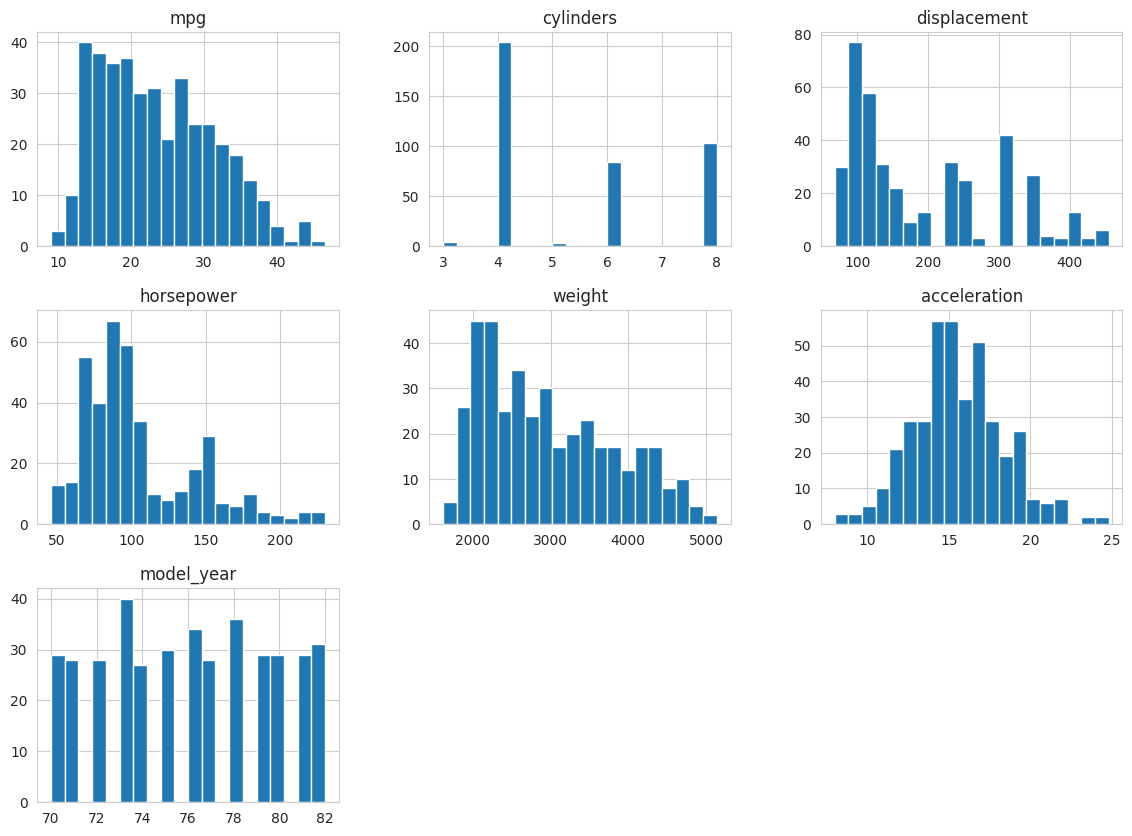

In [6]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
df[num_cols].hist(bins=20, figsize=(14, 10))
plt.show()

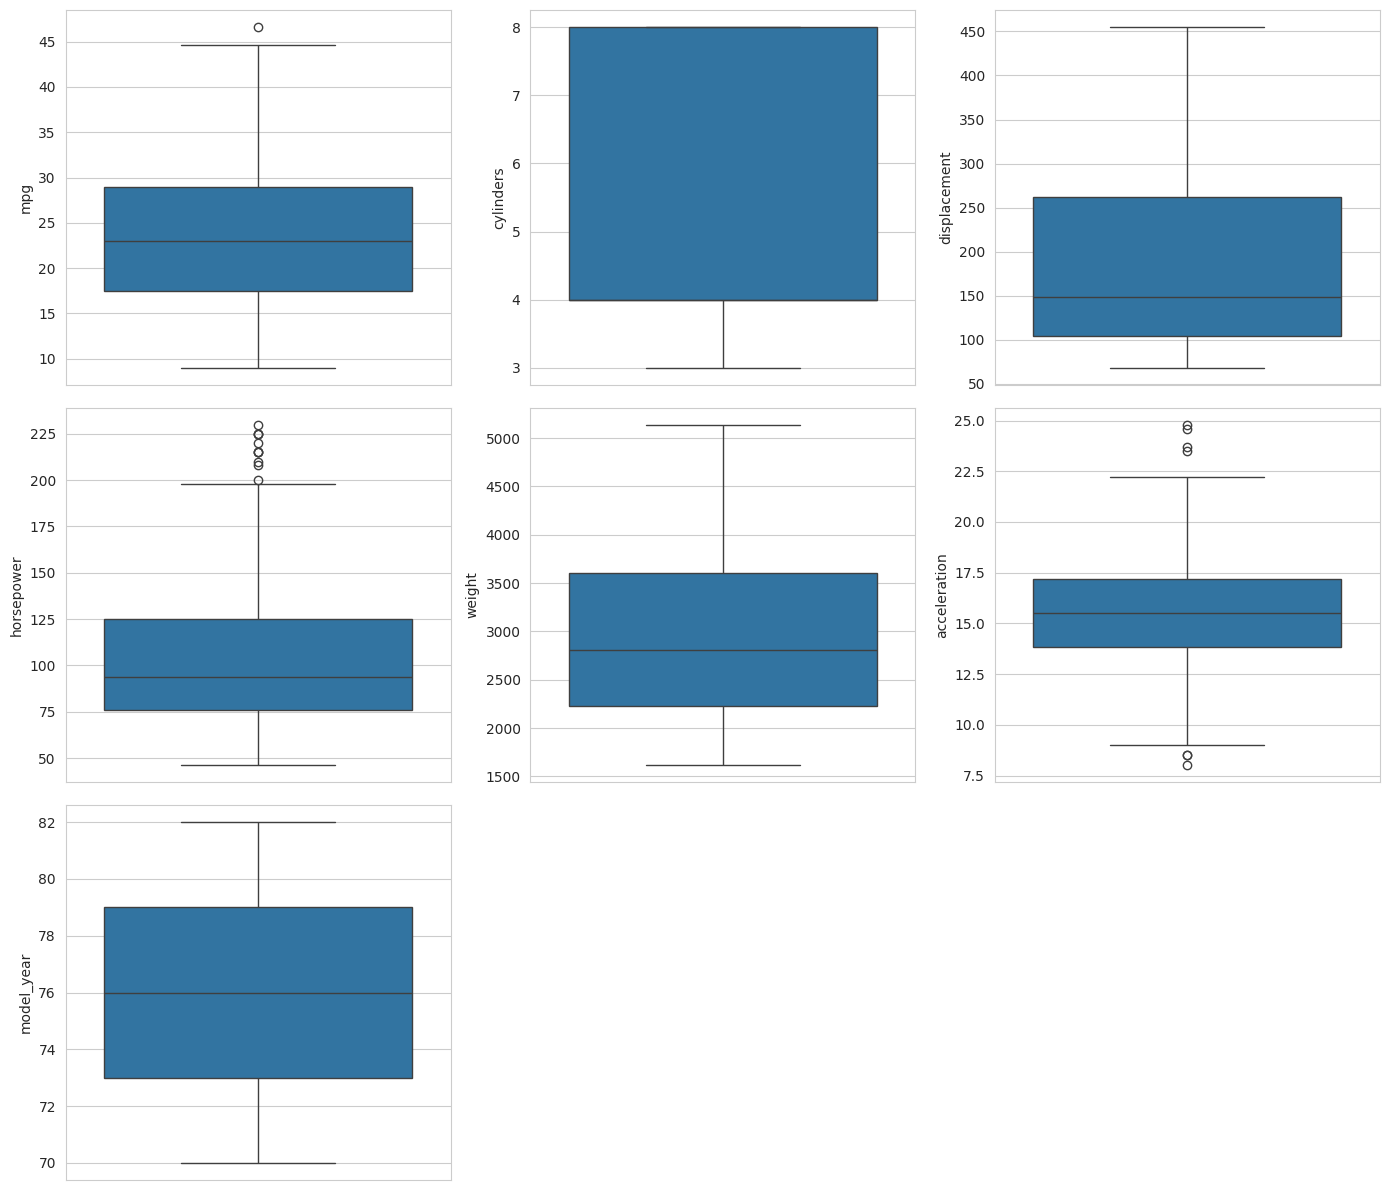

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12)) # Changed from 2,3 to 3,3 to accommodate all columns
for i, col in enumerate(num_cols):
    if i < len(axes.flatten()): # Ensure we don't try to plot more than available axes
        sns.boxplot(data=df, y=col, ax=axes.flatten()[i])

# Hide any unused subplots
for j in range(i + 1, len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


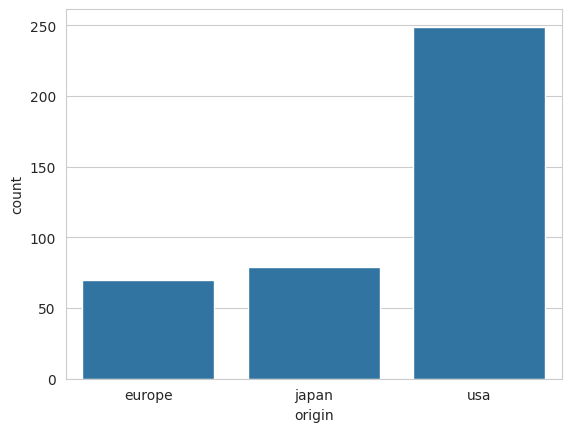

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64


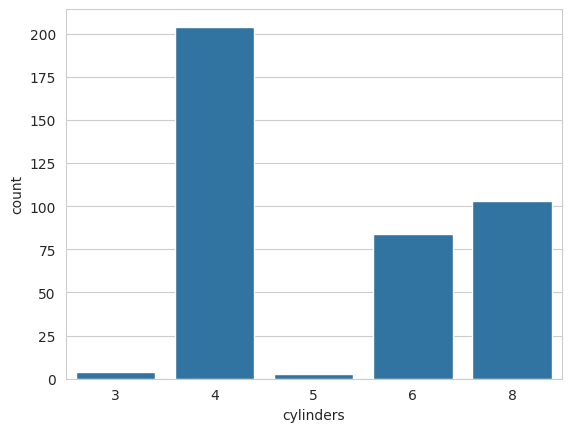

In [9]:
cat_cols = ['origin', 'cylinders']
for col in cat_cols:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.show()

## 3. Análisis bivariante

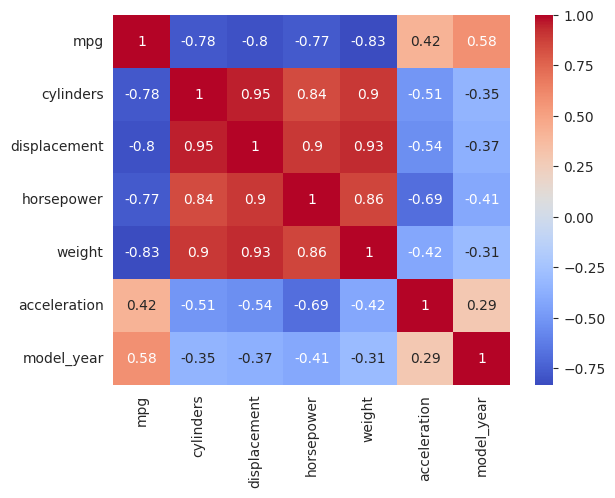

In [10]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

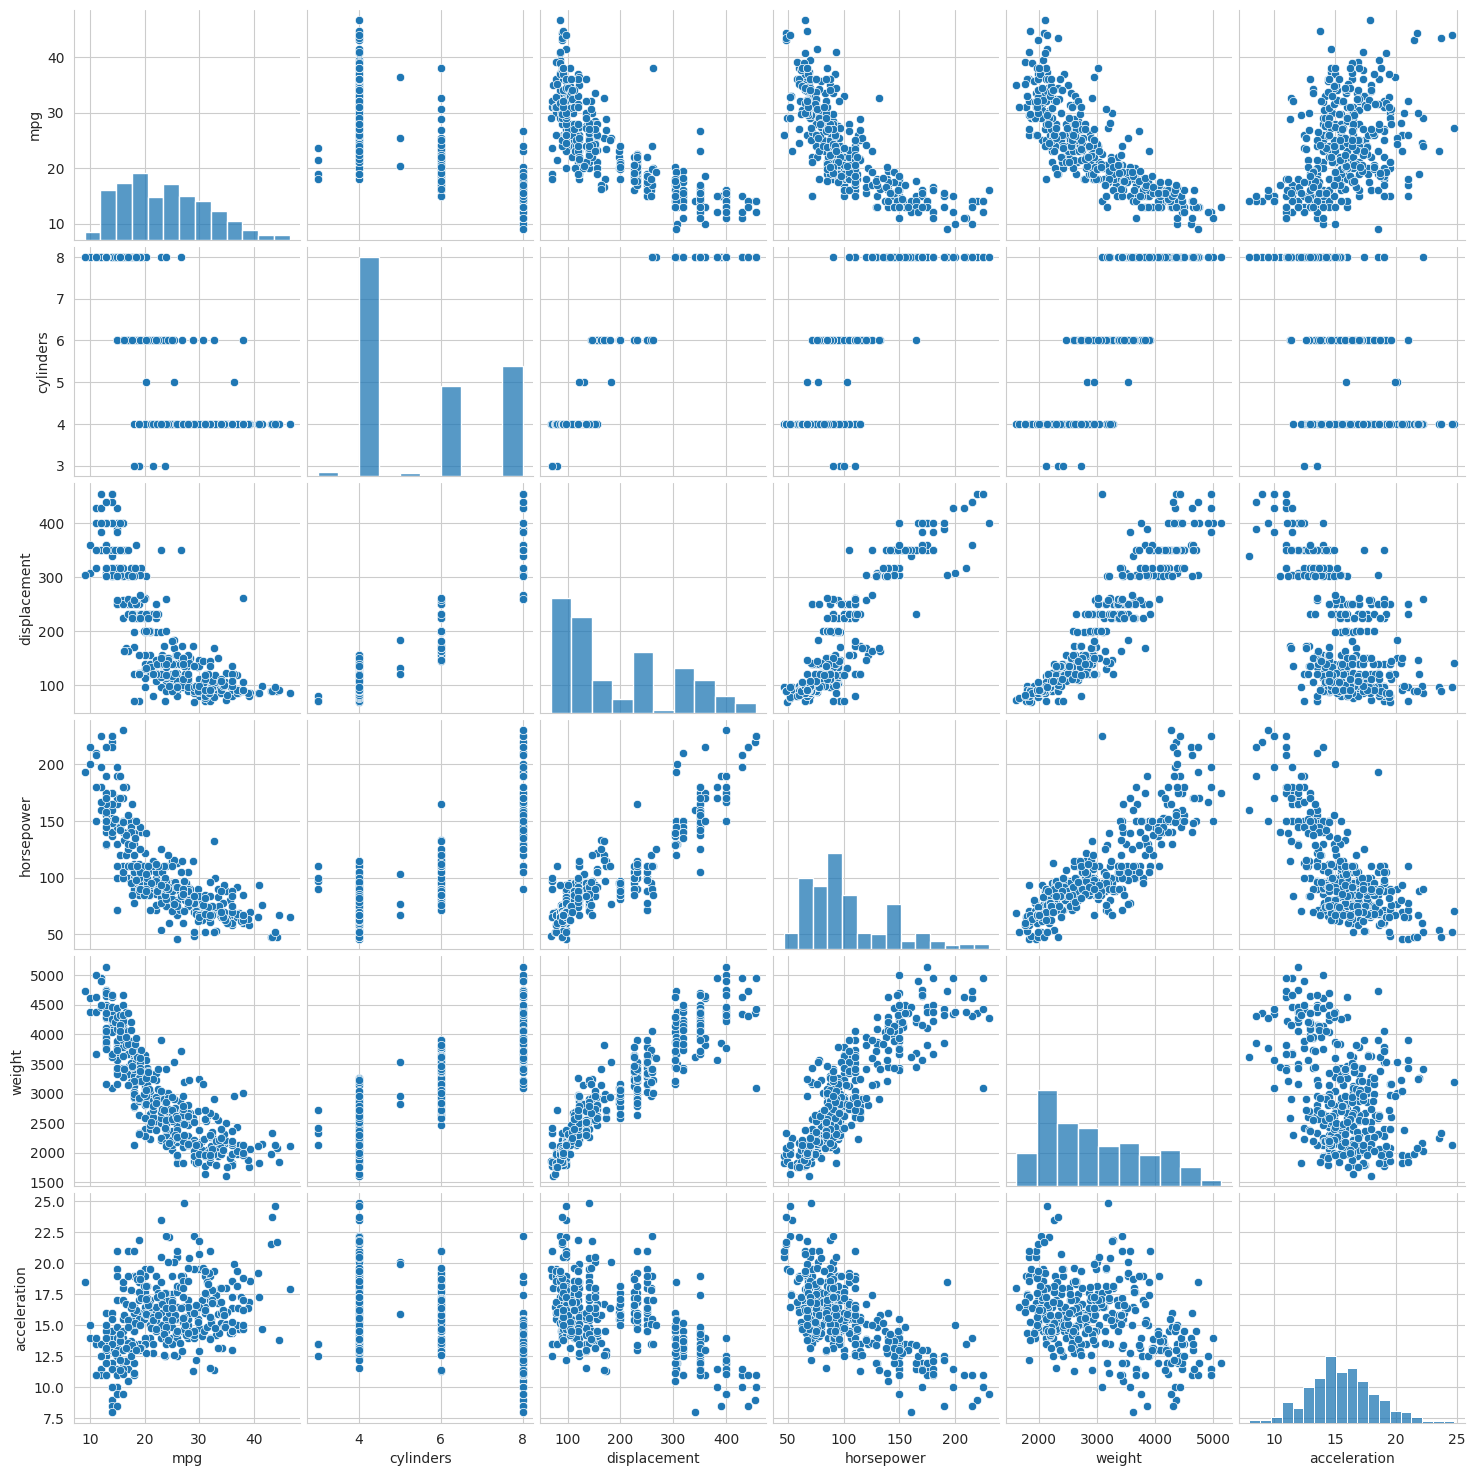

In [11]:
sns.pairplot(df[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']])
plt.show()

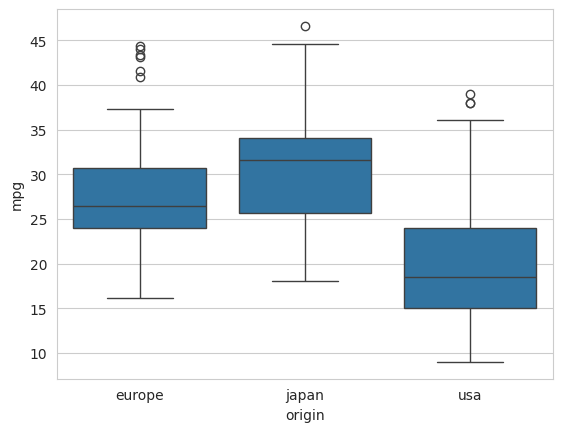

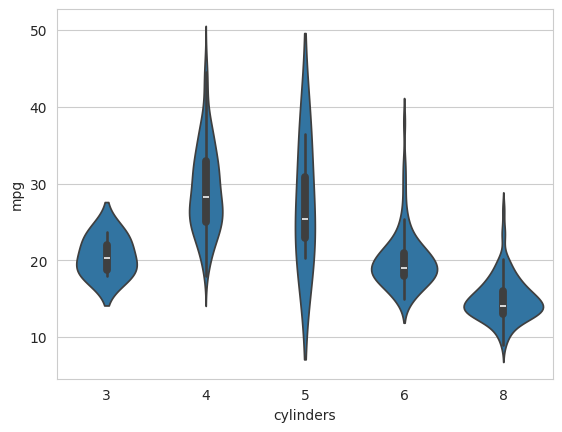

In [12]:
sns.boxplot(data=df, x='origin', y='mpg')
plt.show()
sns.violinplot(data=df, x='cylinders', y='mpg')
plt.show()

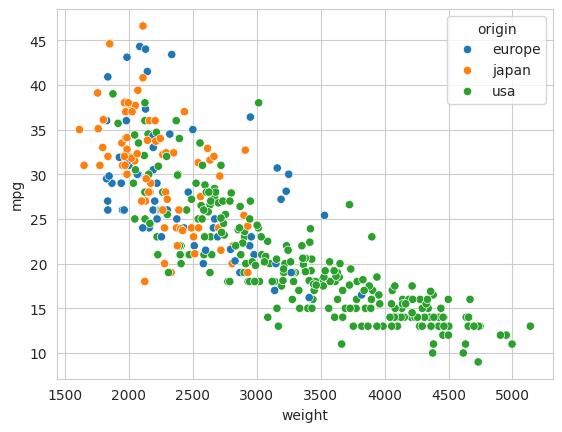

In [13]:
sns.scatterplot(data=df, x='weight', y='mpg', hue='origin')
plt.show()

## 4. Detección de outliers

In [14]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f'{col}: {len(outliers)} outliers')

mpg: 1 outliers
cylinders: 0 outliers
displacement: 0 outliers
horsepower: 11 outliers
weight: 0 outliers
acceleration: 7 outliers
model_year: 0 outliers


## 5. Feature engineering (para EDA)

In [15]:
df['weight_to_hp'] = df['weight'] / df['horsepower']
df['disp_per_cyl'] = df['displacement'] / df['cylinders']
df['mpg_category'] = pd.cut(df['mpg'], bins=[0,20,30,50], labels=['Baja','Media','Alta'])
df['decade'] = (df['model_year'] // 10) * 10
df['decade'] = df['decade'].astype('category')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,weight_to_hp,disp_per_cyl,mpg_category,decade
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,26.953846,38.375,Baja,70
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,22.381818,43.750,Baja,70
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,22.906667,39.750,Baja,70
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,22.886667,38.000,Baja,70
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,24.635714,37.750,Baja,70


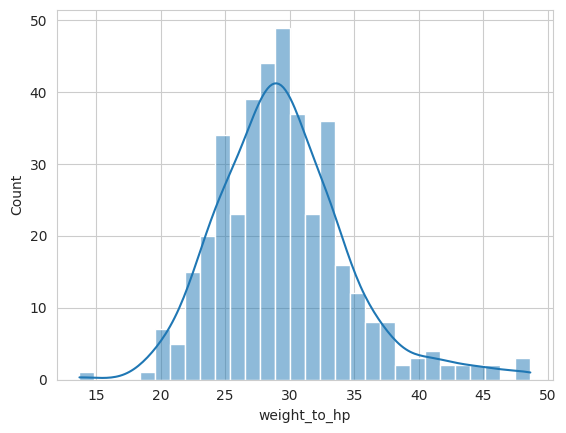

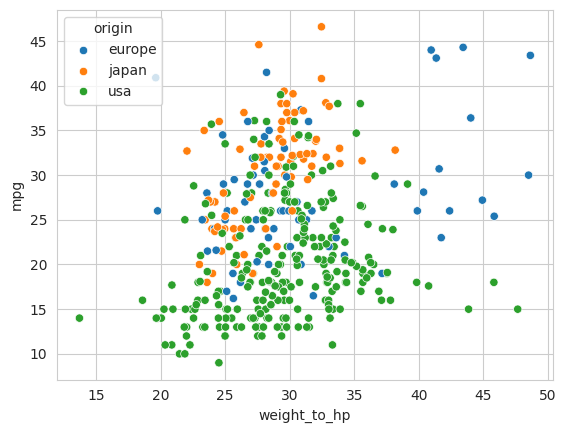

In [16]:
sns.histplot(df['weight_to_hp'], bins=30, kde=True)
plt.show()
sns.scatterplot(data=df, x='weight_to_hp', y='mpg', hue='origin')
plt.show()

## 6. Tendencias temporales

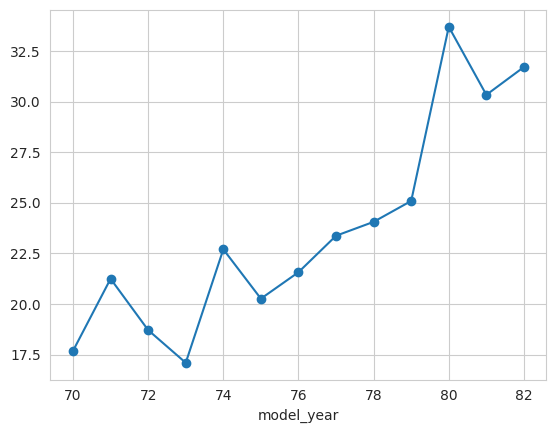

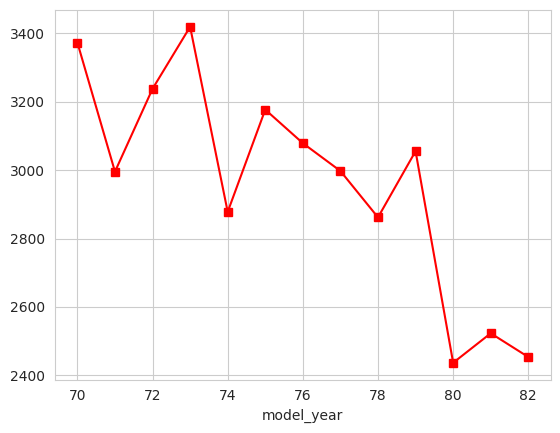

In [17]:
df.groupby('model_year')['mpg'].mean().plot(marker='o')
plt.show()
df.groupby('model_year')['weight'].mean().plot(marker='s', color='red')
plt.show()

## 7. Visualizaciones avanzadas

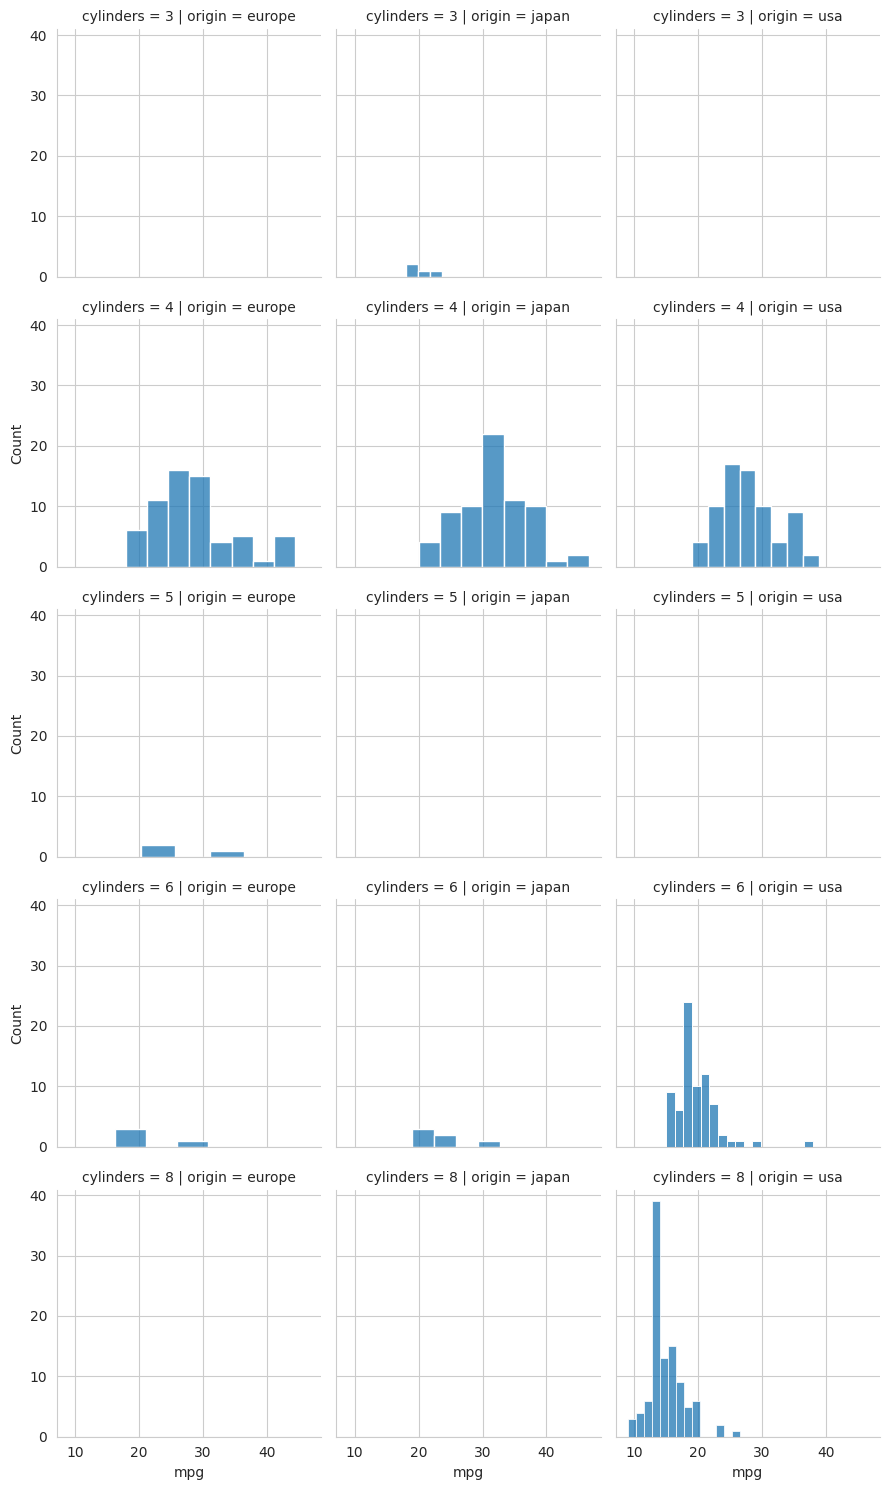

In [18]:
g = sns.FacetGrid(df, col='origin', row='cylinders', height=3)
g.map(sns.histplot, 'mpg')
plt.show()

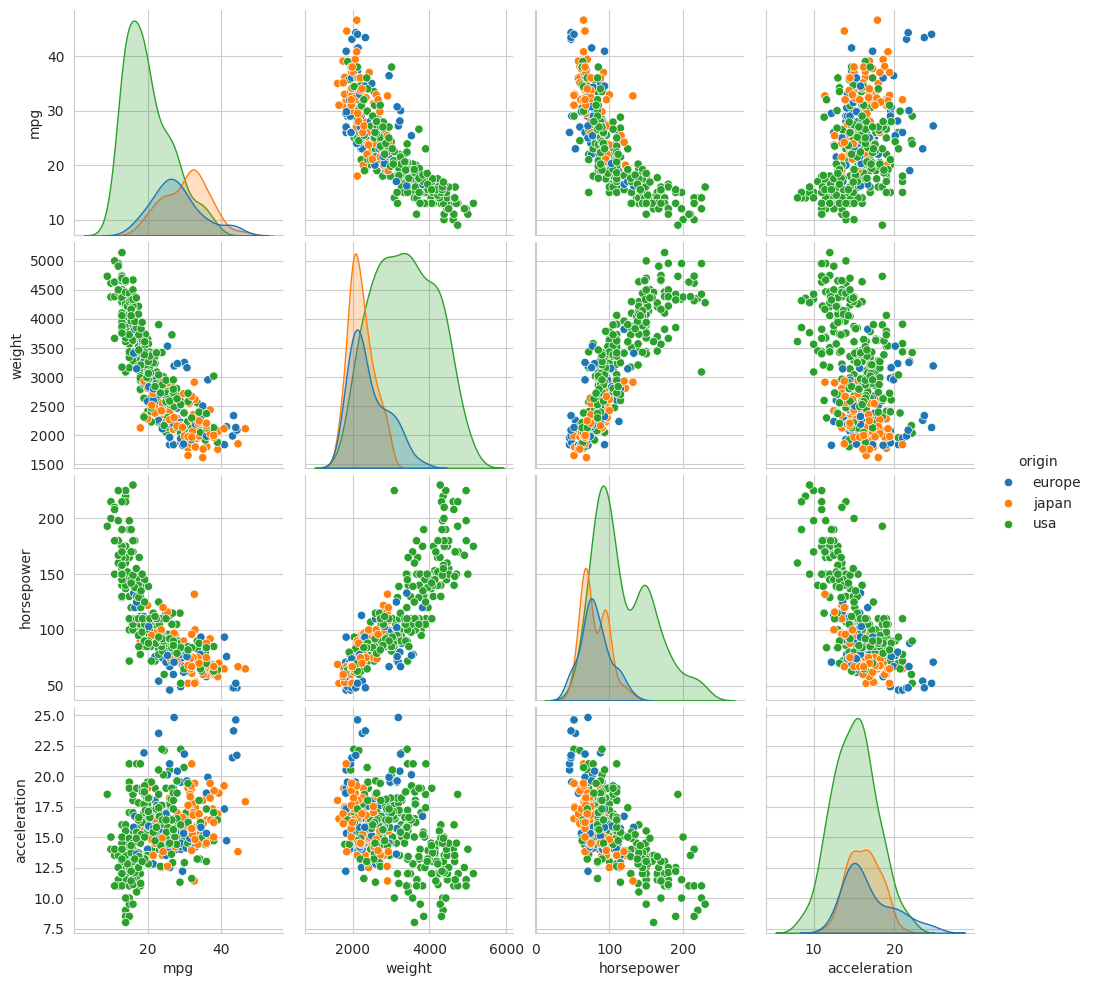

In [19]:
sns.pairplot(df[['mpg', 'weight', 'horsepower', 'acceleration', 'origin']], hue='origin')
plt.show()

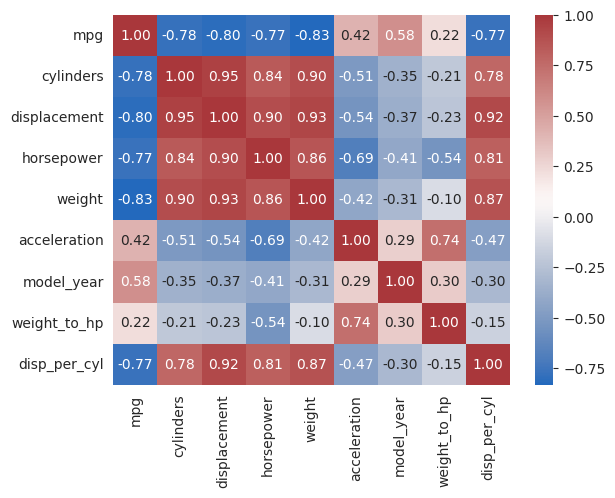

In [20]:
new_num = ['weight_to_hp', 'disp_per_cyl']
all_num = num_cols + new_num
sns.heatmap(df[all_num].corr(), annot=True, cmap='vlag', fmt='.2f')
plt.show()

## 8. Conclusiones
Hemos aplicado técnicas de limpieza, análisis univariante y multivariante, detección de outliers, creación de nuevas variables y visualizaciones avanzadas. Este flujo es replicable en cualquier dataset.